# Week 2: Estimation (Individual)

In Week 1, you explored the system and developed a shared simulation framework.  
In Week 2, you will begin working individually to extract useful structure from the observed data.

## Objective

The internal state of the system is not directly observable. Your task is to design an approach that uses the available observations (and inputs) to construct a useful representation of the system.

There is **no single correct method**. You are expected to logically propose, clearly justify, and meaningfully evaluate your own approach.

## What does “estimation” mean here?

Depending on your design choices, your method need to aim to:

- identify patterns or structure in the observations,
- predict future observations,
- reconstruct hidden variables,
- compress the data into a lower-dimensional representation,
- extract features that can later be used for control.

## Tasks

You should:

1. **Define your objective**  
   Decide what you are trying to estimate and why it is useful.

2. **Design an approach**  
   Propose one or more methods based on your understanding of the system. Where possible, explore different approaches rather than relying on a single method, and compare their performance. Select the approach you consider most effective and justify your choice. Clearly state any assumptions you make.

3. **Implement your method**  
   Build on the Week 1 codebase. Test it on at least one simulation from Week 1. Your implementation does not need to be perfect, but it should be coherent and testable.

4. **Evaluate performance**  
   Use plots and quantitative measures to assess your method. Consider:
   - sensitivity to noise,
   - stability over time,
   - generalisation across different input patterns.

5. **Reflect on limitations**  
   Identify what your method does not capture and what could be improved.

## Guidance
- You may use both observations \(y(t)\) and inputs \(u(t)\). But inputs are not 100% reliable.
- You may use past data (history) if helpful.
- Simpler methods are acceptable if they are clearly justified and well analysed.
- A partially successful but well-explained approach is better than a complex but poorly understood one.

## Week 2 deliverable
**Deliverable:** Interim Report + code.
**Marks:** 20 individual marks.
**Due:** Friday 29 May at 9:00am BST. 

## Testing and evaluating your interface
On **Friday 29 May between 11am and 1pm**, the demonstrator will test your estimator to ensure that your interface meets the required specifications.  

This session is **compulsory** and important for your understanding and progression to the next stage of the project.

## Interim report guidance
Your interim report should be concise and focused, approximately **4 pages** in length, and must not exceed **5 pages total**, including figures and any appendix material.

The report should include:

- A brief description of the system and the simulations you have run,
- A summary of your Week 1 exploration,
- A clear description of your estimation approach,
- Initial results, with figures, demonstrating depth of analysis rather than broad but superficial coverage,
- A discussion of limitations and planned next steps.

The goal of the interim report is to demonstrate your understanding so far and to receive feedback ahead of the final stage.

## Connection to later work
Your estimation approach will form the basis for your control strategy in Week 3.  
Think ahead about how your representation could be used to influence the system.

## Estimation interface

To make testing and evaluation consistent across students, all estimation methods must follow the interface below.

You are free to implement any estimation strategy internally, provided that your function:
- accepts observations as input,
- returns estimated latent states and estimated inputs,
- and preserves the required function signature.

### Important:
- Do not change the function signature of `estimate_latent_and_input`. The demonstrator will call this function to evaluate your solution during the Week 2 evaluation session.
- You may implement any logic inside the function, but it must return:
   1. estimated latent states with shape (Timepoints, LatentDim)
   2. estimated inputs with shape (Timepoints, InputDim)
- If your method uses additional hyperparameters, use partial functions or wrapper functions to fix them before submission. You will not have the opportunity to adjust hyperparameters during the test. Automatic parameter tuning is welcome.


In [2]:
from Jerry_liu_yhl63 import _identify, _smooth, _JITTER
from typing import Tuple
import numpy as np

def evaluate_model(
    observation: np.ndarray, LatentDim: int, InputDim: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    Y = np.asarray(observation, dtype=float)
    if Y.ndim != 2:
        raise ValueError(f"expected observation of shape (T, p); got {Y.shape}")
    T, p = Y.shape
    n, m = int(LatentDim), int(InputDim)

    F = np.eye(m)
    scale = float(np.var(np.diff(Y, axis=0))) if T > 1 else 1.0
    Sigma_u = np.eye(m) * max(scale, _JITTER)

    params = _identify(Y, n, m, F, Sigma_u)
    x_hat, u_hat = _smooth(Y, params, n, m, F, Sigma_u)

    assert x_hat.shape == (T, n) and u_hat.shape == (T, m)
    return x_hat, u_hat, params


In [3]:
import numpy as np

data = np.load("ExampleDataset.npy")
print(
    "Dataset loaded successfully. Shape:", data.shape
)  # (Trials, Timepoints, Neurons)



Dataset loaded successfully. Shape: (5, 60, 16)


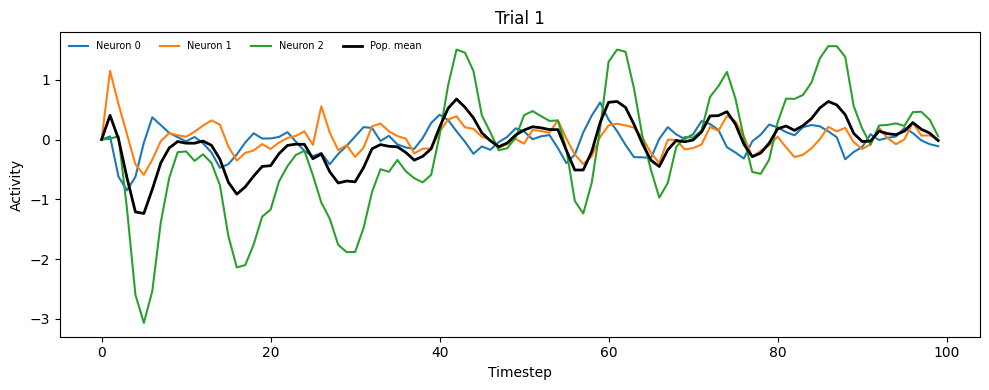

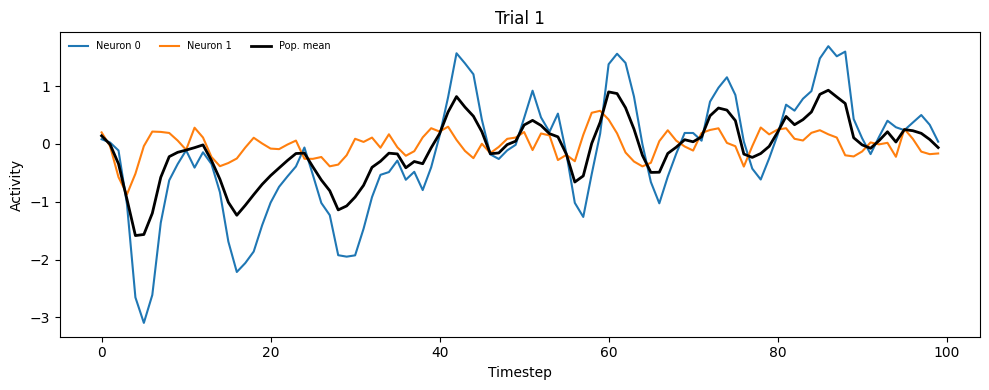

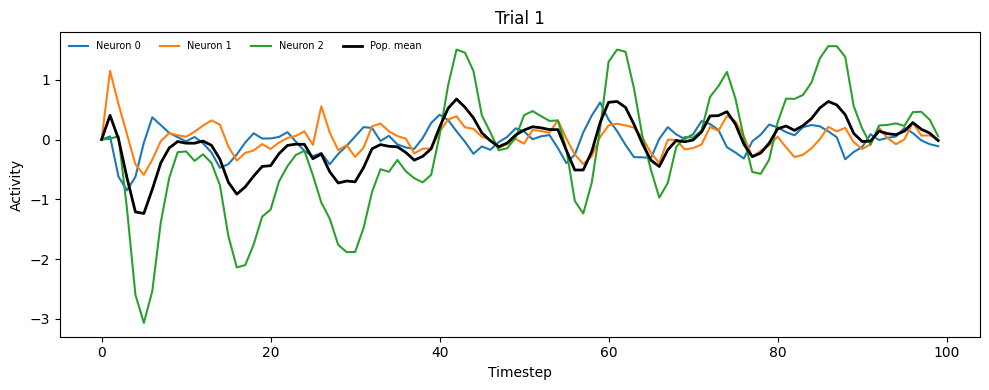

In [4]:
from l4b import Simulator
from l4b import Illustrator

angle = 45 / 180 * np.pi
A = np.array([
    [0.8 * np.cos(angle), -0.8 * np.sin(angle), 0],
    [0.8 * np.sin(angle), 0.8 * np.cos(angle), 0],
    [2, 0, 0.8]
])

B = np.array([[0], [1.0], [0]])

C = np.array([
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0]
])

inputs = np.zeros((100, 1))
inputs[0] = 1
inputs[25] = 0.5
inputs[50] = 0.25

x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.01, (100, 2))


test_transitional_growth = Simulator(
    model=(
        {
            "state_dim": 3,
            "input_dim": 1,
            "obs_dim": 2,

            "A": A,
                
            "B": B,

            "C": C,

            "D": 0,

            "Q": np.eye(3) * 0.01,
        
            "R": np.eye(2) * 0.01,
        }
    )
)
states, observations = test_transitional_growth.run(
    initial_state=np.array([0, 0, 0]), control_inputs=inputs, time_steps=100, trials=1
)

obsersavation_plot = Illustrator(observations)
latent_plot = Illustrator(states)
obsersavation_plot.plot_trials()
latent_plot.plot_trials()


In [5]:
LatentDim, InputDim = 3, 1
estimated_latent_states, estimated_inputs, model_params = evaluate_model(
    observations[0], LatentDim, InputDim)


observations = Illustrator(observations).plot_trials()
latent_states = Illustrator(np.array([estimated_latent_states])).plot_trials()
inputs = Illustrator(np.array([estimated_inputs])).plot_trials()
print(model_params)


test = Simulator(
    model=(
        {
            "state_dim": estimated_latent_states.shape[1],
            "input_dim": estimated_inputs.shape[1],
            "obs_dim": 16,

            "A": model_params[0],
                
            "B": model_params[1],

            "C": model_params[2],

            "D": model_params[3],

            "Q": model_params[4],
        
            "R": model_params[5],
        }
    )
)

states, observations = test.run(
    initial_state=estimated_latent_states[0], control_inputs=estimated_inputs, time_steps=60, trials=1
)

fig = Illustrator(observations).plot_trials()

observations = Illustrator(np.array([data[0]])).plot_trials()
latent_states = Illustrator(np.array([estimated_latent_states])).plot_trials()
inputs = Illustrator(np.array([estimated_inputs])).plot_trials()
print(model_params)



2 3 1


ValueError: operands could not be broadcast together with shapes (2,2) (2,3) 

SyntaxError: invalid syntax (381759391.py, line 1)

I've now got the full picture: the generative model, your augmented‑state EM estimator, and all 18 test cases. Here's a structured walkthrough.

The generative model under test
From SimulationIllustrationFuncs.py the simulator is strictly causal:

$$x_t = A,x_{t-1} + B,u_{t-1} + w_t,\qquad y_t = C,x_t + v_t,\qquad x_0=w_0$$

with $w_t\sim\mathcal N(0,Q)$, $v_t\sim\mathcal N(0,R)$. The estimator is blind: it sees only $Y\in\mathbb R^{T\times p}$ plus the dimensions $(n,m)$, and must return $\hat x\in\mathbb R^{T\times n}$ and $\hat u\in\mathbb R^{T\times m}$.

How the LGSSM design recovers both state and input
Your estimator (Jerry_liu_yhl63.py) folds the unknown input into the state with a random‑walk prior $u_{t+1}=u_t+\eta_t$ and augments $z_t=[x_t;u_t]$:

$$
z_{t+1}=\underbrace{\begin{bmatrix}A&B\0&I\end{bmatrix}}{\tilde A}z_t+\tilde w_t,\qquad
y_t=\underbrace{\begin{bmatrix}C&D\end{bmatrix}}{\tilde C}z_t+v_t,\qquad \tilde Q=\mathrm{diag}(Q,\Sigma_u)
$$

This turns a forced system into an ordinary noise‑driven LGSSM, so a single mechanism — Kalman filter + RTS smoother — yields both quantities as the leading $n$ and trailing $m$ smoothed coordinates. The free blocks $(A,B,C,D,Q,R)$ are learned by EM (E‑step = smoother, M‑step = closed‑form regression on smoothed moments), warm‑started from PCA of the observations, with restarts to guard against local optima. Three design levers determine how each test case is handled:

The zero lower‑left block of $\tilde A$ (exogeneity: input drives state, not vice‑versa) is the structural constraint that separates "input" from "state" — it is not preserved by a similarity transform, so it carries identifying information.
The random‑walk prior $\Sigma_u$ distinguishes input coordinates by their temporal smoothness.
Likelihood + known $R$ lets the smoother weight noisy channels optimally rather than by raw variance.
The two input families
The cases split into two regimes that stress the prior differently:

Sparse Impulse Input (Cases 1–14): inputs are isolated spikes. These are adversarial to the AR(1) prior — the smoother smears and attenuates sharp transitions (lab notebook §5.3). Gauge‑aligned $R^2$ is the fair metric.
Min‑energy Input (Cases 1–4): inputs are minimum‑energy control signals that drive the noiseless latent through waypoints — smooth, low‑frequency, and therefore well matched to the random‑walk prior.
Sparse‑impulse cases, by the challenge each probes
Case	Label	What it stresses	How the augmented LGSSM copes
1	baseline	$p{=}16\gg n{=}3$, full‑rank $C$, good SNR	Trivial: $C$ full column rank ⇒ near‑instantaneous observability; EM, PCA, subspace all succeed
2	null‑space injection	$B{=}[1,1,0]$ vs $C$ row $[1,-1,0]$: input excites a near‑unobservable direction	Recovery leans on $A$‑coupling + prior; left‑invertibility is marginal, so estimate is prior‑dependent
3	null‑space injection	Nearly collinear $C$ rows; input again in weak‑observability direction	Same — needs the dynamics, not the instantaneous map, to see $u$
4	ill‑conditioned	$A{=}[[0.9,1],[0,0.01]]$ — strongly non‑normal; mode 0.01 decays instantly but kicks the slow mode	Variance ranking misleads (fast mode ≈ no energy); EM's predictive objective keeps it
5	ill‑conditioned	3‑D non‑normal, large off‑diagonals, separated timescales	Likelihood weights modes by predictability, not variance
6	transitional growth	$A[2,0]{=}2$ feeds a third mode; $p{=}2<n{=}3$ (under‑observed)	Needs history/observability through $A$; static methods blind to the hidden mode
7	hidden driven osc	$B{=}[0,0,1]$ drives coord 2 which $C$ does not observe; it reaches output only via $A[0,2]{=}0.3$	Reconstructed purely through the dynamics — a model‑based smoother's strength
8	high‑low freq	Two oscillator blocks, slow (0.98, 4°) + fast (0.95, 40°), anisotropic	Both modes captured if latent dim is right; wide spectral spread stresses conditioning
9	noisy	$p{=}32$, $R$‑noise $\sigma{=}1.5\gg$ signal	Many channels + known $R$ ⇒ Kalman averages noise out; naive subspace degrades
10	short time	$T{=}10$, $p{=}64$, $n{=}3$	Parametric model + warm start + prior still give a (regularised) fit
11	inadequate latents	True system is 4‑D, estimator told $n{=}2$	Under‑specified — best 2‑D predictive approximation; some dynamics unmodelled
12	overcomplex assumption	True 4‑D, estimator told $n{=}8$	Over‑specified — extra states risk fitting noise; prior/regularisation matters
13	low output dim	$p{=}1$; $B$ drives coord 0, seen only via $A[2,0]{=}0.8$	Reconstruct 3‑D state + input from a scalar — pure observability‑through‑dynamics
14	no‑input, noise‑driven	$u\equiv 0$; system driven purely by $w_t$; non‑normal $A$	Estimator should return $\hat u\approx 0$; a pure stochastic realisation
Min‑energy cases reuse the null‑space geometry (Cases 1–2) and add strongly non‑normal plants (Cases 3–4, "use non‑normality") where the min‑energy controller exploits transient amplification — small smooth inputs producing large state excursions. These are the cases your AR(1) prior is built for.

Which case would defeat a subspace method — and why
Case 10 (Short Time, $T=10$).

Subspace identification (N4SID / MOESP — the Van Overschee & De Moor procedures your notebook cites in §4.5) recovers the extended observability matrix from the row/column spaces of block‑Hankel data matrices. Splitting the record into past/future blocks of $i$ lags gives Hankel matrices of size $(i\cdot p)\times(T-2i+1)$, and the method is statistically consistent only asymptotically, requiring far more columns than rows so the oblique projection and its SVD are well‑defined.

With $T=10$ and $p=64$, even $i=2$ produces a $128\times 7$ past block: catastrophically rank‑deficient, with essentially no columns to estimate covariances from. The SVD rank‑selection step that is subspace identification becomes meaningless — there is no reliable singular‑value gap, and the recovered "subspace" is noise. The model‑based EM estimator, by contrast, has a finite parameterisation, a PCA warm start, an informative prior, and restarts, so it still returns a regularised estimate from 10 samples. This is the cleanest, most unambiguous subspace‑failure case.

A related, secondary failure worth flagging if "subspace method" is read in the variance‑projection sense (PCA/SSA, §4.1–4.3): the ill‑conditioned / non‑normal cases (4, 5, 6). Variance‑subspace methods rank directions by retained energy, but in a strongly non‑normal plant the dynamically essential mode can carry almost no variance (e.g. the eigenvalue‑0.01 mode in Case 4) while a transiently amplified direction dominates the spectrum. The leading‑variance subspace then misaligns with the true state subspace — the exact "variance ≠ predictability" gap your §4.4 uses to motivate the move to an LGSSM. And in either sense, Case 14 (zero input) is degenerate for subspace input identification: with no excitation, $B$ and the input direction are simply not identifiable from data — only a prior can resolve them.

Net: if you want a single answer, it's Case 10 — short data is the canonical setting where the asymptotic, data‑hungry subspace machinery collapses while the likelihood‑based augmented LGSSM still works.